In [6]:
import gzip
import shutil
import os

# Paths to your STARE dataset
IMAGE_DIR = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\stare-images"
MASK_DIR = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\labels-ah"

def extract_gz_files(folder):
    files = [f for f in os.listdir(folder) if f.endswith(".gz")]
    for f in files:
        gz_path = os.path.join(folder, f)
        out_path = os.path.join(folder, f.replace(".gz",""))
        with gzip.open(gz_path, "rb") as gz_file:
            with open(out_path, "wb") as out_file:
                shutil.copyfileobj(gz_file, out_file)
        print("Extracted:", f)

# Extract images and masks
extract_gz_files(IMAGE_DIR)
extract_gz_files(MASK_DIR)


Extracted: im0001.ppm.gz
Extracted: im0002.ppm.gz
Extracted: im0003.ppm.gz
Extracted: im0004.ppm.gz
Extracted: im0005.ppm.gz
Extracted: im0044.ppm.gz
Extracted: im0077.ppm.gz
Extracted: im0081.ppm.gz
Extracted: im0082.ppm.gz
Extracted: im0139.ppm.gz
Extracted: im0162.ppm.gz
Extracted: im0163.ppm.gz
Extracted: im0235.ppm.gz
Extracted: im0236.ppm.gz
Extracted: im0239.ppm.gz
Extracted: im0240.ppm.gz
Extracted: im0255.ppm.gz
Extracted: im0291.ppm.gz
Extracted: im0319.ppm.gz
Extracted: im0324.ppm.gz
Extracted: im0001.ah.ppm.gz
Extracted: im0002.ah.ppm.gz
Extracted: im0003.ah.ppm.gz
Extracted: im0004.ah.ppm.gz
Extracted: im0005.ah.ppm.gz
Extracted: im0044.ah.ppm.gz
Extracted: im0077.ah.ppm.gz
Extracted: im0081.ah.ppm.gz
Extracted: im0082.ah.ppm.gz
Extracted: im0139.ah.ppm.gz
Extracted: im0162.ah.ppm.gz
Extracted: im0163.ah.ppm.gz
Extracted: im0235.ah.ppm.gz
Extracted: im0236.ah.ppm.gz
Extracted: im0239.ah.ppm.gz
Extracted: im0240.ah.ppm.gz
Extracted: im0255.ah.ppm.gz
Extracted: im0291.ah.ppm

C:\Users\AUSTCSE4090\anaconda3\envs\py310\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Total images: 20
Total masks: 20
Train images: 15
Train masks: 15
Test images: 5
Test masks: 5
Datasets ready: train_ds, test_ds
Total patches: 100


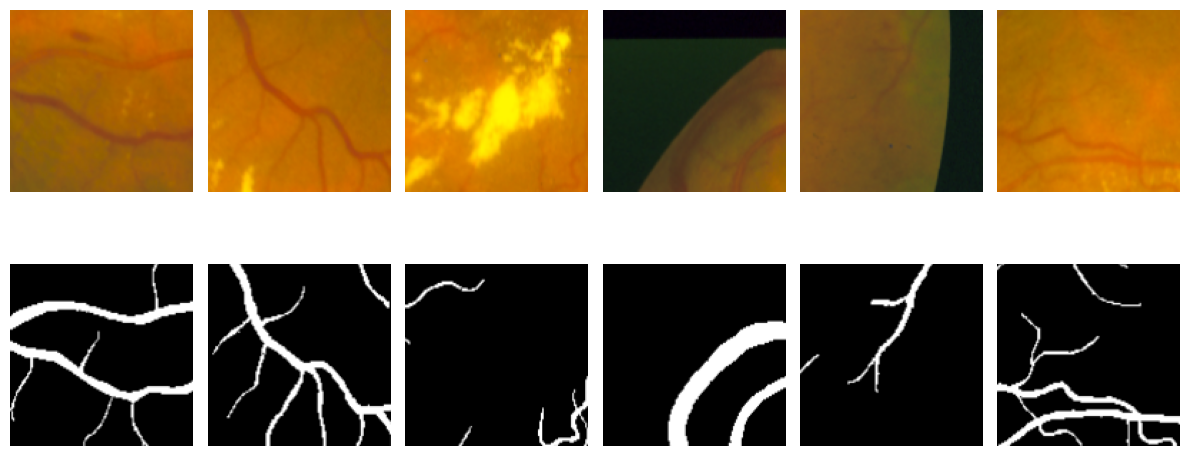

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import matplotlib.pyplot as plt
import random
import gzip
import shutil

# ================= PATHS =================
IMAGE_DIR = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\stare-images"
MASK_DIR = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\labels-ah"

# ================= CONSTANTS =================
RESIZE_SIZE = 704  # Resize original images to 768x768
IMG_SIZE = 128     # Patch size
OVERLAP = 0.5
BATCH_SIZE = 8

# ================= AUGMENTATION =================
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
])

# ================= DECOMPRESSION FUNCTIONS =================
def decompress_ppm_gz(input_path, output_path):
    """Decompress .ppm.gz files to .ppm."""
    with gzip.open(input_path, 'rb') as f_in:
        with open(output_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

def decompress_all_files(image_dir, mask_dir):
    """Decompress all .ppm.gz files in image and mask directories."""
    for dir_path in [image_dir, mask_dir]:
        for filename in os.listdir(dir_path):
            if filename.endswith('.ppm.gz'):
                input_path = os.path.join(dir_path, filename)
                output_path = os.path.join(dir_path, filename.replace('.gz', ''))
                print(f"Decompressing: {filename}")
                decompress_ppm_gz(input_path, output_path)
                os.remove(input_path)  # Optionally remove the original .gz file

# ================= FUNCTIONS =================
def is_valid_patch(mask, threshold=0.01):
    """Check if the patch contains a significant portion of the object."""
    return np.count_nonzero(mask) / mask.size > threshold

def extract_patches(img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    """Extract patches from the image and mask."""
    stride = int(patch_size * (1 - overlap))
    patches_img = []
    patches_mask = []
    H, W = img.shape[:2]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            p_img = img[y:y+patch_size, x:x+patch_size]
            p_mask = mask[y:y+patch_size, x:x+patch_size]

            if skip_empty and not is_valid_patch(p_mask):
                continue

            patches_img.append(p_img)
            patches_mask.append(p_mask)

    return patches_img, patches_mask

def load_image_mask_paths(image_dir, mask_dir):
    """Load image and mask file paths."""
    image_files = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith('.ppm')  # Now looking for .ppm files
    ])
    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith('.ppm')  # Looking for .ppm mask files
    ])
    return image_files, mask_files

def generator(image_paths, mask_paths, augment=True, skip_empty=True):
    """Generator function to yield image-mask pairs."""
    for img_path, mask_path in zip(image_paths, mask_paths):

        # Read images
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize to 768x768
        img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
        mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

        # Extract patches
        patches_img, patches_mask = extract_patches(
            img, mask, IMG_SIZE, OVERLAP, skip_empty
        )

        for p_img, p_mask in zip(patches_img, patches_mask):

            if augment:
                data = augmenter(image=p_img, mask=p_mask)
                p_img, p_mask = data["image"], data["mask"]

            p_img = p_img.astype(np.float32) / 255.0
            p_mask = np.expand_dims(p_mask.astype(np.float32) / 255.0, axis=-1)

            yield p_img, p_mask

# ================= DECOMPRESS FILES =================
# Decompress all .ppm.gz files before loading them
decompress_all_files(IMAGE_DIR, MASK_DIR)

# ================= LOAD PATHS =================
all_images, all_masks = load_image_mask_paths(IMAGE_DIR, MASK_DIR)

# Debugging: Check if the images and masks were loaded correctly
print(f"Total images: {len(all_images)}")
print(f"Total masks: {len(all_masks)}")

# ===== Manual split: FIRST 15 → train, LAST 5 → test =====
train_images = all_images[:15]   # Use first 15 images for training
train_masks  = all_masks[:15]    # Use first 15 masks for training

test_images  = all_images[15:20]  # Use next 5 images for testing
test_masks   = all_masks[15:20]   # Use next 5 masks for testing

# Debugging: Print the size of training and testing splits
print(f"Train images: {len(train_images)}")  # Should print 15
print(f"Train masks: {len(train_masks)}")    # Should print 15
print(f"Test images: {len(test_images)}")    # Should print 5
print(f"Test masks: {len(test_masks)}")      # Should print 5

# ================= TF.DATA DATASETS =================
train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_images, train_masks, augment=True, skip_empty=True),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_images, test_masks, augment=False, skip_empty=False),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets ready: train_ds, test_ds")

# ================= VISUALIZATION =================
def visualize_patches(img_path, mask_path, num_samples=6):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize for visualization
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
    mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

    patches_img, patches_mask = extract_patches(
        img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=False
    )

    print(f"Total patches: {len(patches_img)}")

    indices = random.sample(range(len(patches_img)), min(num_samples, len(patches_img)))

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        plt.subplot(2, num_samples, i+1)
        plt.imshow(patches_img[idx])
        plt.axis("off")

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(patches_mask[idx], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example visualization
visualize_patches(train_images[0], train_masks[0])


In [2]:
# ================= LOAD PATHS =================
all_images, all_masks = load_image_mask_paths(IMAGE_DIR, MASK_DIR)

# Debugging: Check if the images and masks were loaded correctly
print(f"Total images: {len(all_images)}")
print(f"Total masks: {len(all_masks)}")


Total images: 20
Total masks: 20


In [3]:
# ================= COUNT TRAINING & TEST PATCHES =================
def count_patches(image_paths, mask_paths, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    total_patches = 0
    for img_path, mask_path in zip(image_paths, mask_paths):

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        patches_img, patches_mask = extract_patches(img, mask, patch_size, overlap, skip_empty)
        total_patches += len(patches_img)

    return total_patches


train_patch_count = count_patches(train_images, train_masks, skip_empty=True)
test_patch_count  = count_patches(test_images, test_masks, skip_empty=False)

print(f"Total training patches: {train_patch_count}")
print(f"Total test patches: {test_patch_count}")


Total training patches: 1062
Total test patches: 360


In [4]:
import tensorflow as tf
from tensorflow.keras import backend as K

def confusion_elements(y_true, y_pred):
    """Helper to calculate TP, TN, FP, FN"""
    y_pred = K.round(y_pred)
    y_true = K.round(y_true)
    TP = K.sum(y_true * y_pred)
    TN = K.sum((1 - y_true) * (1 - y_pred))
    FP = K.sum((1 - y_true) * y_pred)
    FN = K.sum(y_true * (1 - y_pred))
    return TP, TN, FP, FN

# Sensitivity (Recall)
def sensitivity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FN + K.epsilon())

# Specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TN / (TN + FP + K.epsilon())

# Accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN + K.epsilon())

# Precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FP + K.epsilon())

# F1-score
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = sensitivity(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec + K.epsilon()))

# AUC (use Keras built-in metric)
auc = tf.keras.metrics.AUC(name='auc')


import tensorflow as tf
import tensorflow.keras.backend as K

smooth = 1e-6

def iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(K.round(y_pred), tf.float32)  # Round to binary
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(K.round(y_pred))  # Round predictions to binary
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [5]:

from __future__ import absolute_import

from keras_unet_collection.layer_utils import *
from keras_unet_collection.activations import GELU, Snake
from keras_unet_collection._model_unet_2d import UNET_left, UNET_right
from keras_unet_collection.transformer_layers import patch_extract, patch_embedding
from keras_unet_collection._backbone_zoo import backbone_zoo, bach_norm_checker

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, MultiHeadAttention, LayerNormalization, Dense, Embedding
    
def ViT_MLP(X, filter_num, activation='GELU', name='MLP'):
    '''
    The MLP block of ViT.
    
    ----------
    Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, 
    T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S. and Uszkoreit, J., 2020. 
    An image is worth 16x16 words: Transformers for image recognition at scale. 
    arXiv preprint arXiv:2010.11929.
    
    Input
    ----------
        X: the input tensor of MLP, i.e., after MSA and skip connections
        filter_num: a list that defines the number of nodes for each MLP layer.
                        For the last MLP layer, its number of node must equal to the dimension of key.
        activation: activation of MLP nodes.
        name: prefix of the created keras layers.
        
    Output
    ----------
        V: output tensor.

    '''
    activation_func = eval(activation)
    
    for i, f in enumerate(filter_num):
        X = Dense(f, name='{}_dense_{}'.format(name, i))(X)
        X = activation_func(name='{}_activation_{}'.format(name, i))(X)
        
    return X
    
def ViT_block(V, num_heads, key_dim, filter_num_MLP, activation='GELU', name='ViT'):
    '''
    
    Vision transformer (ViT) block.
    
    ViT_block(V, num_heads, key_dim, filter_num_MLP, activation='GELU', name='ViT')
    
    ----------
    Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, 
    T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S. and Uszkoreit, J., 2020. 
    An image is worth 16x16 words: Transformers for image recognition at scale. 
    arXiv preprint arXiv:2010.11929.
    
    Input
    ----------
        V: embedded input features.
        num_heads: number of attention heads.
        key_dim: dimension of the attention key (equals to the embeded dimensions).
        filter_num_MLP: a list that defines the number of nodes for each MLP layer.
                        For the last MLP layer, its number of node must equal to the dimension of key.
        activation: activation of MLP nodes.
        name: prefix of the created keras layers.
        
    Output
    ----------
        V: output tensor.
    
    '''
    # Multiheaded self-attention (MSA)
    V_atten = V # <--- skip
    V_atten = LayerNormalization(name='{}_layer_norm_1'.format(name))(V_atten)
    V_atten = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, 
                                 name='{}_atten'.format(name))(V_atten, V_atten)
    # Skip connection
    V_add = add([V_atten, V], name='{}_skip_1'.format(name)) # <--- skip
    
    # MLP
    V_MLP = V_add # <--- skip
    V_MLP = LayerNormalization(name='{}_layer_norm_2'.format(name))(V_MLP)
    V_MLP = ViT_MLP(V_MLP, filter_num_MLP, activation, name='{}_mlp'.format(name))
    # Skip connection
    V_out = add([V_MLP, V_add], name='{}_skip_2'.format(name)) # <--- skip
    
    return V_out


def transunet_2d_base(input_tensor, filter_num, stack_num_down=2, stack_num_up=2, 
                      embed_dim=768, num_mlp=3072, num_heads=12, num_transformer=12,
                      activation='ReLU', mlp_activation='GELU', batch_norm=False, pool=True, unpool=True, 
                      backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):
    '''
    The base of transUNET with an optional ImageNet-trained backbone.
    
    ----------
    Chen, J., Lu, Y., Yu, Q., Luo, X., Adeli, E., Wang, Y., Lu, L., Yuille, A.L. and Zhou, Y., 2021. 
    Transunet: Transformers make strong encoders for medical image segmentation. arXiv preprint arXiv:2102.04306.
    
    Input
    ----------
        input_tensor: the input tensor of the base, e.g., `keras.layers.Inpyt((None, None, 3))`.
        filter_num: a list that defines the number of filters for each \
                    down- and upsampling levels. e.g., `[64, 128, 256, 512]`.
                    The depth is expected as `len(filter_num)`.
        stack_num_down: number of convolutional layers per downsampling level/block. 
        stack_num_up: number of convolutional layers (after concatenation) per upsampling level/block.
        activation: one of the `tensorflow.keras.layers` or `keras_unet_collection.activations` interfaces, e.g., 'ReLU'.
        batch_norm: True for batch normalization.
        pool: True or 'max' for MaxPooling2D.
              'ave' for AveragePooling2D.
              False for strided conv + batch norm + activation.
        unpool: True or 'bilinear' for Upsampling2D with bilinear interpolation.
                'nearest' for Upsampling2D with nearest interpolation.
                False for Conv2DTranspose + batch norm + activation.
        name: prefix of the created keras model and its layers.
        
        ---------- (keywords of ViT) ----------
        embed_dim: number of embedded dimensions.
        num_mlp: number of MLP nodes.
        num_heads: number of attention heads.
        num_transformer: number of stacked ViTs.
        mlp_activation: activation of MLP nodes.
        
        ---------- (keywords of backbone options) ----------
        backbone_name: the bakcbone model name. Should be one of the `tensorflow.keras.applications` class.
                       None (default) means no backbone. 
                       Currently supported backbones are:
                       (1) VGG16, VGG19
                       (2) ResNet50, ResNet101, ResNet152
                       (3) ResNet50V2, ResNet101V2, ResNet152V2
                       (4) DenseNet121, DenseNet169, DenseNet201
                       (5) EfficientNetB[0-7]
        weights: one of None (random initialization), 'imagenet' (pre-training on ImageNet), 
                 or the path to the weights file to be loaded.
        freeze_backbone: True for a frozen backbone.
        freeze_batch_norm: False for not freezing batch normalization layers.
        
    Output
    ----------
        X: output tensor.
    
    '''
    activation_func = eval(activation)
    
    X_skip = []
    depth_ = len(filter_num)
    
    # ----- internal parameters ----- #
    
    # patch size (fixed to 1-by-1)
    patch_size = 1
    
    # input tensor size
    input_size = input_tensor.shape[1]
    
    # encoded feature map size
    encode_size = input_size // 2**(depth_-1)
    
    # number of size-1 patches
    num_patches = encode_size ** 2 
    
    # dimension of the attention key (= dimension of embedings)
    key_dim = embed_dim
    
    # number of MLP nodes
    filter_num_MLP = [num_mlp, embed_dim]
    
    # ----- UNet-like downsampling ----- #
    
    # no backbone cases
    if backbone is None:

        X = input_tensor

        # stacked conv2d before downsampling
        X = CONV_stack(X, filter_num[0], stack_num=stack_num_down, activation=activation, 
                       batch_norm=batch_norm, name='{}_down0'.format(name))
        X_skip.append(X)

        # downsampling blocks
        for i, f in enumerate(filter_num[1:]):
            X = UNET_left(X, f, stack_num=stack_num_down, activation=activation, pool=pool, 
                          batch_norm=batch_norm, name='{}_down{}'.format(name, i+1))        
            X_skip.append(X)

    # backbone cases
    else:
        # handling VGG16 and VGG19 separately
        if 'VGG' in backbone:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip)
            
        # for other backbones
        else:
            backbone_ = backbone_zoo(backbone, weights, input_tensor, depth_-1, freeze_backbone, freeze_batch_norm)
            # collecting backbone feature maps
            X_skip = backbone_([input_tensor,])
            depth_encode = len(X_skip) + 1


        # extra conv2d blocks are applied
        # if downsampling levels of a backbone < user-specified downsampling levels
        if depth_encode < depth_:

            # begins at the deepest available tensor  
            X = X_skip[-1]

            # extra downsamplings
            for i in range(depth_-depth_encode):
                i_real = i + depth_encode

                X = UNET_left(X, filter_num[i_real], stack_num=stack_num_down, activation=activation, pool=pool, 
                              batch_norm=batch_norm, name='{}_down{}'.format(name, i_real+1))
                X_skip.append(X)
        
    # subtrack the last tensor (will be replaced by the ViT output)
    X = X_skip[-1]
    X_skip = X_skip[:-1]

    # 1-by-1 linear transformation before entering ViT blocks
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_before'.format(name))(X)

    X = patch_extract((patch_size, patch_size))(X)
    X = patch_embedding(num_patches, embed_dim)(X)

    # stacked ViTs 
    for i in range(num_transformer):
        X = ViT_block(X, num_heads, key_dim, filter_num_MLP, activation=mlp_activation, 
                      name='{}_ViT_{}'.format(name, i))

    # reshape patches to feature maps
    X = tf.reshape(X, (-1, encode_size, encode_size, embed_dim))

    # 1-by-1 linear transformation to adjust the number of channels
    X = Conv2D(filter_num[-1], 1, padding='valid', use_bias=False, name='{}_conv_trans_after'.format(name))(X)

    X_skip.append(X)
    
    # ----- UNet-like upsampling ----- #
    
    # reverse indexing encoded feature maps
    X_skip = X_skip[::-1]
    # upsampling begins at the deepest available tensor
    X = X_skip[0]
    # other tensors are preserved for concatenation
    X_decode = X_skip[1:]
    depth_decode = len(X_decode)

    # reverse indexing filter numbers
    filter_num_decode = filter_num[:-1][::-1]

    # upsampling with concatenation
    for i in range(depth_decode):
        X = UNET_right(X, [X_decode[i],], filter_num_decode[i], stack_num=stack_num_up, activation=activation, 
                       unpool=unpool, batch_norm=batch_norm, name='{}_up{}'.format(name, i))

    # if tensors for concatenation is not enough
    # then use upsampling without concatenation 
    if depth_decode < depth_-1:
        for i in range(depth_-depth_decode-1):
            i_real = i + depth_decode
            X = UNET_right(X, None, filter_num_decode[i_real], stack_num=stack_num_up, activation=activation, 
                       unpool=unpool, batch_norm=batch_norm, concat=False, name='{}_up{}'.format(name, i_real))
            
    return X

def transunet_2d(input_size, filter_num, n_labels, stack_num_down=2, stack_num_up=2,
                 embed_dim=768, num_mlp = 3072, num_heads=12, num_transformer=12,
                 activation='ReLU', mlp_activation='GELU', output_activation='Softmax', batch_norm=False, pool=True, unpool=True, 
                 backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet'):
    '''
    TransUNET with an optional ImageNet-trained bakcbone.
    
    
    ----------
    Chen, J., Lu, Y., Yu, Q., Luo, X., Adeli, E., Wang, Y., Lu, L., Yuille, A.L. and Zhou, Y., 2021. 
    Transunet: Transformers make strong encoders for medical image segmentation. arXiv preprint arXiv:2102.04306.
    
    Input
    ----------
        input_size: the size/shape of network input, e.g., `(128, 128, 3)`.
        filter_num: a list that defines the number of filters for each \
                    down- and upsampling levels. e.g., `[64, 128, 256, 512]`.
                    The depth is expected as `len(filter_num)`.
        n_labels: number of output labels.
        stack_num_down: number of convolutional layers per downsampling level/block. 
        stack_num_up: number of convolutional layers (after concatenation) per upsampling level/block.
        activation: one of the `tensorflow.keras.layers` or `keras_unet_collection.activations` interfaces, e.g., 'ReLU'.
        output_activation: one of the `tensorflow.keras.layers` or `keras_unet_collection.activations` interface or 'Sigmoid'.
                           Default option is 'Softmax'.
                           if None is received, then linear activation is applied.
        batch_norm: True for batch normalization.
        pool: True or 'max' for MaxPooling2D.
              'ave' for AveragePooling2D.
              False for strided conv + batch norm + activation.
        unpool: True or 'bilinear' for Upsampling2D with bilinear interpolation.
                'nearest' for Upsampling2D with nearest interpolation.
                False for Conv2DTranspose + batch norm + activation.                 
        name: prefix of the created keras model and its layers.
        
        ---------- (keywords of ViT) ----------
        embed_dim: number of embedded dimensions.
        num_mlp: number of MLP nodes.
        num_heads: number of attention heads.
        num_transformer: number of stacked ViTs.
        mlp_activation: activation of MLP nodes.
        
        ---------- (keywords of backbone options) ----------
        backbone_name: the bakcbone model name. Should be one of the `tensorflow.keras.applications` class.
                       None (default) means no backbone. 
                       Currently supported backbones are:
                       (1) VGG16, VGG19
                       (2) ResNet50, ResNet101, ResNet152
                       (3) ResNet50V2, ResNet101V2, ResNet152V2
                       (4) DenseNet121, DenseNet169, DenseNet201
                       (5) EfficientNetB[0-7]
        weights: one of None (random initialization), 'imagenet' (pre-training on ImageNet), 
                 or the path to the weights file to be loaded.
        freeze_backbone: True for a frozen backbone.
        freeze_batch_norm: False for not freezing batch normalization layers.
        
    Output
    ----------
        model: a keras model.
    
    '''
    
    activation_func = eval(activation)
        
    IN = Input(input_size)
    
    # base    
    X = transunet_2d_base(IN, filter_num, stack_num_down=stack_num_down, stack_num_up=stack_num_up, 
                          embed_dim=embed_dim, num_mlp=num_mlp, num_heads=num_heads, num_transformer=num_transformer,
                          activation=activation, mlp_activation=mlp_activation, batch_norm=batch_norm, pool=pool, unpool=unpool,
                          backbone=backbone, weights=weights, freeze_backbone=freeze_backbone, freeze_batch_norm=freeze_batch_norm, name=name)
    
    # output layer
    OUT = CONV_output(X, n_labels, kernel_size=1, activation=output_activation, name='{}_output'.format(name))
    
    # functional API model
    model = Model(inputs=[IN,], outputs=[OUT,], name='{}_model'.format(name))
    
    return model
  

In [6]:
# Define input size, filter_num, and other parameters
input_size = (128, 128, 3)  # example input size
filter_num = [64, 128, 256, 512]  # example filter sizes
n_labels = 1  # binary segmentation, so only 1 output class (foreground vs background)

# Create the TransUNet model for binary segmentation
model = transunet_2d(input_size=input_size, filter_num=filter_num, n_labels=n_labels,
                     stack_num_down=2, stack_num_up=2, embed_dim=768, num_mlp=3072,
                     num_heads=12, num_transformer=12, activation='ReLU', mlp_activation='GELU',
                     output_activation='Sigmoid', batch_norm=False, pool=True, unpool=True, 
                     backbone=None, weights='imagenet', freeze_backbone=True, freeze_batch_norm=True, name='transunet')

# Now call summary on the created model
model.summary()


Model: "transunet_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 transunet_down0_0 (Conv2D)     (None, 128, 128, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 transunet_down0_0_activation (  (None, 128, 128, 64  0          ['transunet_down0_0[0][0]']      
 ReLU)                          )                                                   

In [7]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ----------------------------------
# Tversky Index
# ----------------------------------
def tversky(y_true, y_pred, alpha=0.7, beta=0.3):
    # numerical stability
    y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)

    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    

    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)

    return (true_pos + 1e-6) / (
        true_pos + alpha * false_neg + beta * false_pos + 1e-6
    )


# ----------------------------------
# Focal Tversky Loss
# ----------------------------------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    tv = tversky(y_true, y_pred)
    return K.pow((1 - tv), gamma)


# ----------------------------------
# Hybrid Loss (Recommended)
# ----------------------------------
def hybrid_loss(y_true, y_pred):
    ft = focal_tversky_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.7 * ft + 0.3 * bce


In [8]:
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.optimizers import Adam


# Define Adam optimizer with an initial learning rate
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)


def lr_schedule(epoch, lr):
    if epoch < 5:  # Warmup phase
        return lr * 1.5  # Increase LR to stabilize training
    elif epoch < 30:
        return lr * 0.98  # Gradual decay
    else:
        return lr * 0.95  # Final stabilization

lr_scheduler = LearningRateScheduler(lr_schedule)

In [9]:
from tensorflow.keras.losses import BinaryCrossentropy
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True),
    lr_scheduler
    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]



# Compile the model
model.compile(
    optimizer=optimizer,
    loss= hybrid_loss,  # Use BCE loss for binary segmentation
    metrics=[sensitivity, specificity, accuracy, f1_score, auc,dice_coef,iou]  # Your custom metrics
)


# Fit the model
history = model.fit(
    train_ds,
    #validation_data=test_ds,
     # optional if dataset is finite
    epochs=80,
)


Epoch 1/80
181/181 [==============================] - 52s 200ms/step - loss: 0.7222 - sensitivity: 0.0244 - specificity: 0.9904 - accuracy: 0.9023 - f1_score: 0.0197 - auc: 0.5662 - dice_coef: 0.0196 - iou: 0.0114
Epoch 2/80
181/181 [==============================] - 36s 191ms/step - loss: 0.6469 - sensitivity: 0.3227 - specificity: 0.9255 - accuracy: 0.8718 - f1_score: 0.3039 - auc: 0.7258 - dice_coef: 0.3023 - iou: 0.1844
Epoch 3/80
181/181 [==============================] - 36s 193ms/step - loss: 0.5691 - sensitivity: 0.4667 - specificity: 0.9406 - accuracy: 0.8978 - f1_score: 0.4527 - auc: 0.7966 - dice_coef: 0.4489 - iou: 0.3004
Epoch 4/80
181/181 [==============================] - 35s 191ms/step - loss: 0.4311 - sensitivity: 0.6508 - specificity: 0.9591 - accuracy: 0.9314 - f1_score: 0.6304 - auc: 0.8861 - dice_coef: 0.6243 - iou: 0.4593
Epoch 5/80
181/181 [==============================] - 35s 192ms/step - loss: 0.3959 - sensitivity: 0.6936 - specificity: 0.9611 - accuracy: 0.93

Mean Dice        : 0.7887
Mean IoU         : 0.6532
Mean Accuracy    : 0.9722
Mean F1 Score    : 0.7887
Mean Sensitivity : 0.7650
Mean Specificity : 0.9878


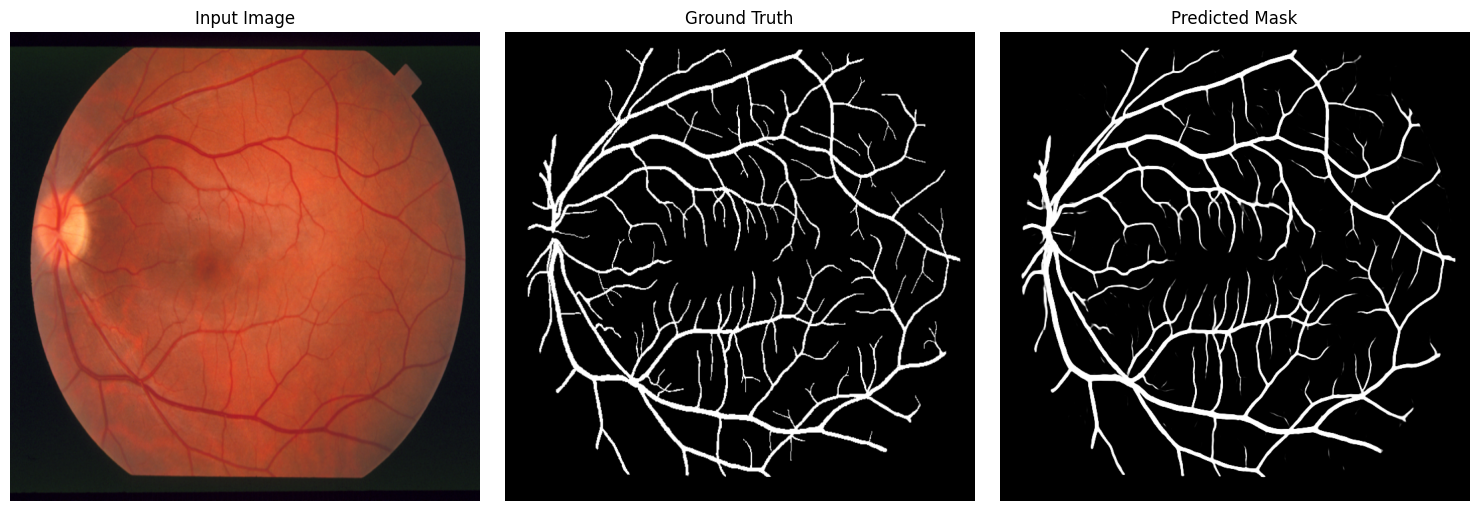

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

#================= CONSTANTS =================

RESIZE_SIZE = 704   # Full image resize
IMG_SIZE    = 128   # Patch size
OVERLAP     = 0.5   # 50% overlap
THRESHOLD   = 0.5   # Binarization threshold
BATCH_SIZE  = 16    # Mini-batch size for patch prediction

#================= PATCH FUNCTIONS =================

def extract_patches(img, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    H, W = img.shape[:2]
    patches = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patches.append(img[y:y+patch_size, x:x+patch_size])
    return patches

def stitch_patches(patches, image_size=RESIZE_SIZE, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    stitched_mask = np.zeros((image_size, image_size), dtype=np.float32)
    count_mask = np.zeros((image_size, image_size), dtype=np.float32)

    idx = 0  
    for y in range(0, image_size - patch_size + 1, stride):  
        for x in range(0, image_size - patch_size + 1, stride):  
            stitched_mask[y:y+patch_size, x:x+patch_size] += patches[idx]  
            count_mask[y:y+patch_size, x:x+patch_size] += 1  
            idx += 1  

    stitched_mask /= count_mask  
    return np.clip(stitched_mask, 0, 1)

#================= FULL IMAGE PREDICTION =================

def predict_full_image(model, img_path, batch_size=BATCH_SIZE):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))

    patches = extract_patches(img)  
    pred_patches = []  

    # Predict in mini-batches  
    for i in range(0, len(patches), batch_size):  
        batch = np.array([p.astype(np.float32)/255.0 for p in patches[i:i+batch_size]])  
        preds = model.predict(batch, verbose=0)  
        pred_patches.extend([p[:, :, 0] for p in preds])  # remove channel dim  

    full_mask = stitch_patches(pred_patches)  
    return img, full_mask

#================= EVALUATION FUNCTION =================

def evaluate_model(model, image_paths, mask_paths):
    dice_list, iou_list, acc_list, f1_list, sens_list, spec_list = [], [], [], [], [], []

    for img_path, mask_path in zip(image_paths, mask_paths):  
        img, pred_mask = predict_full_image(model, img_path)  

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  
        gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0  

        pred_bin = (pred_mask >= THRESHOLD).astype(np.float32)  
        gt_bin   = (gt_mask >= 0.5).astype(np.float32)  

        intersection = np.sum(pred_bin * gt_bin)  
        union = np.sum(pred_bin) + np.sum(gt_bin) - intersection  
        dice = (2 * intersection) / (np.sum(pred_bin) + np.sum(gt_bin) + 1e-7)  
        iou  = intersection / (union + 1e-7)  
        acc  = accuracy_score(gt_bin.flatten(), pred_bin.flatten())  
        f1   = f1_score(gt_bin.flatten(), pred_bin.flatten())  
        sens = recall_score(gt_bin.flatten(), pred_bin.flatten())  
        spec = (np.sum((1 - gt_bin) * (1 - pred_bin)) / np.sum(1 - gt_bin))  

        dice_list.append(dice)  
        iou_list.append(iou)  
        acc_list.append(acc)  
        f1_list.append(f1)  
        sens_list.append(sens)  
        spec_list.append(spec)  

    print(f"Mean Dice        : {np.mean(dice_list):.4f}")  
    print(f"Mean IoU         : {np.mean(iou_list):.4f}")  
    print(f"Mean Accuracy    : {np.mean(acc_list):.4f}")  
    print(f"Mean F1 Score    : {np.mean(f1_list):.4f}")  
    print(f"Mean Sensitivity : {np.mean(sens_list):.4f}")  
    print(f"Mean Specificity : {np.mean(spec_list):.4f}")

#================= VISUALIZATION =================

def visualize_prediction(model, img_path, mask_path):
    img, pred_mask = predict_full_image(model, img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    plt.figure(figsize=(15,5))  
    plt.subplot(1,3,1)  
    plt.imshow(img)  
    plt.title("Input Image")  
    plt.axis("off")  

    plt.subplot(1,3,2)  
    plt.imshow(gt_mask, cmap="gray")  
    plt.title("Ground Truth")  
    plt.axis("off")  

    plt.subplot(1,3,3)  
    plt.imshow(pred_mask, cmap="gray")  
    plt.title("Predicted Mask")  
    plt.axis("off")  

    plt.tight_layout()  
    plt.show()

#================= USAGE =================

# Evaluate all test images
evaluate_model(model, test_images, test_masks)

# Visualize first test image
visualize_prediction(model, test_images[1], test_masks[1])


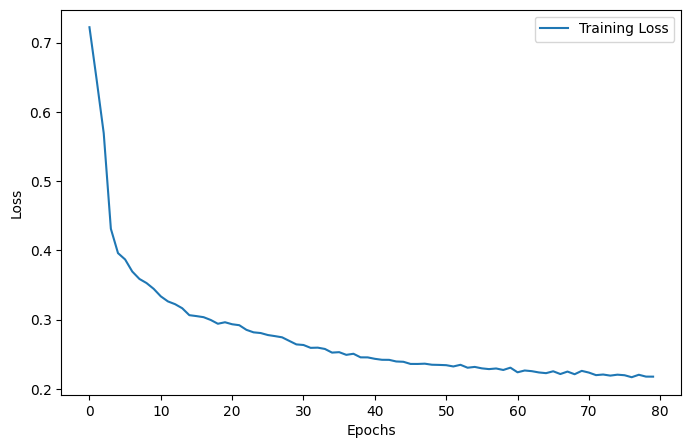

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Metrics for Image 1: Sens: 0.726, Spec: 0.987, Acc: 0.960, F1: 0.789, Dice: 0.789, IoU: 0.652


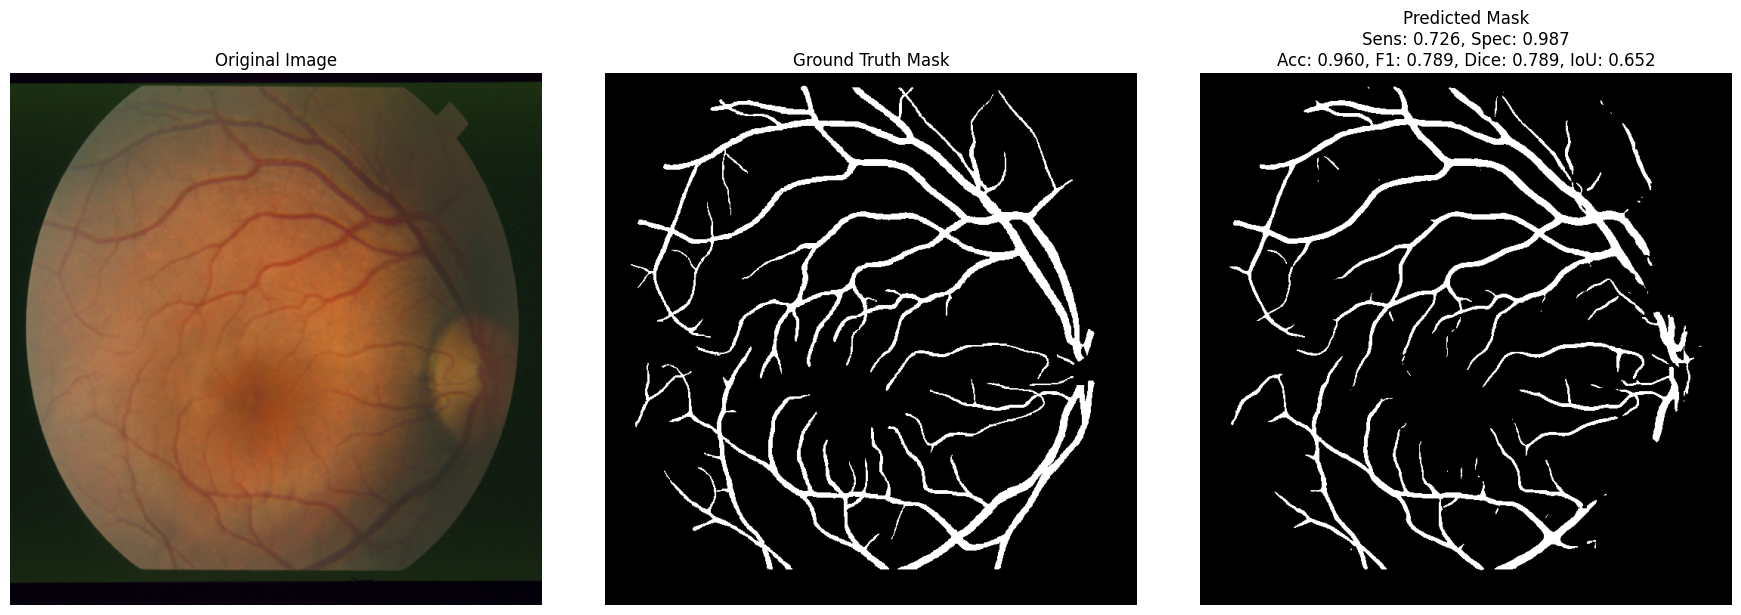

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet original image\original_image_1.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet predicted_mask\predicted_mask_1.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet_ground_truth_mask\ground_truth_mask_1.png
Metrics for Image 1 written to CSV.
Metrics for Image 2: Sens: 0.864, Spec: 0.984, Acc: 0.974, F1: 0.854, Dice: 0.854, IoU: 0.746


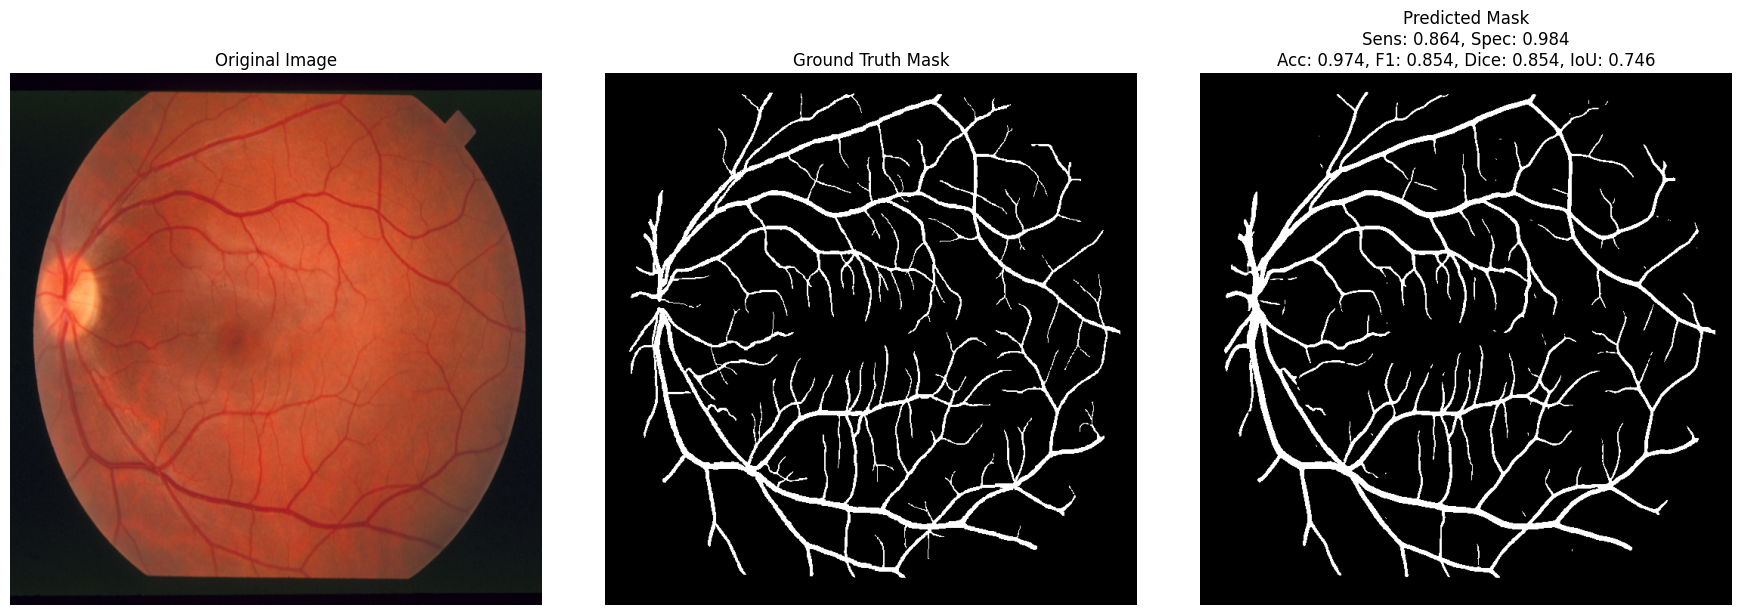

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet original image\original_image_2.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet predicted_mask\predicted_mask_2.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet_ground_truth_mask\ground_truth_mask_2.png
Metrics for Image 2 written to CSV.
Metrics for Image 3: Sens: 0.786, Spec: 0.991, Acc: 0.981, F1: 0.807, Dice: 0.807, IoU: 0.676


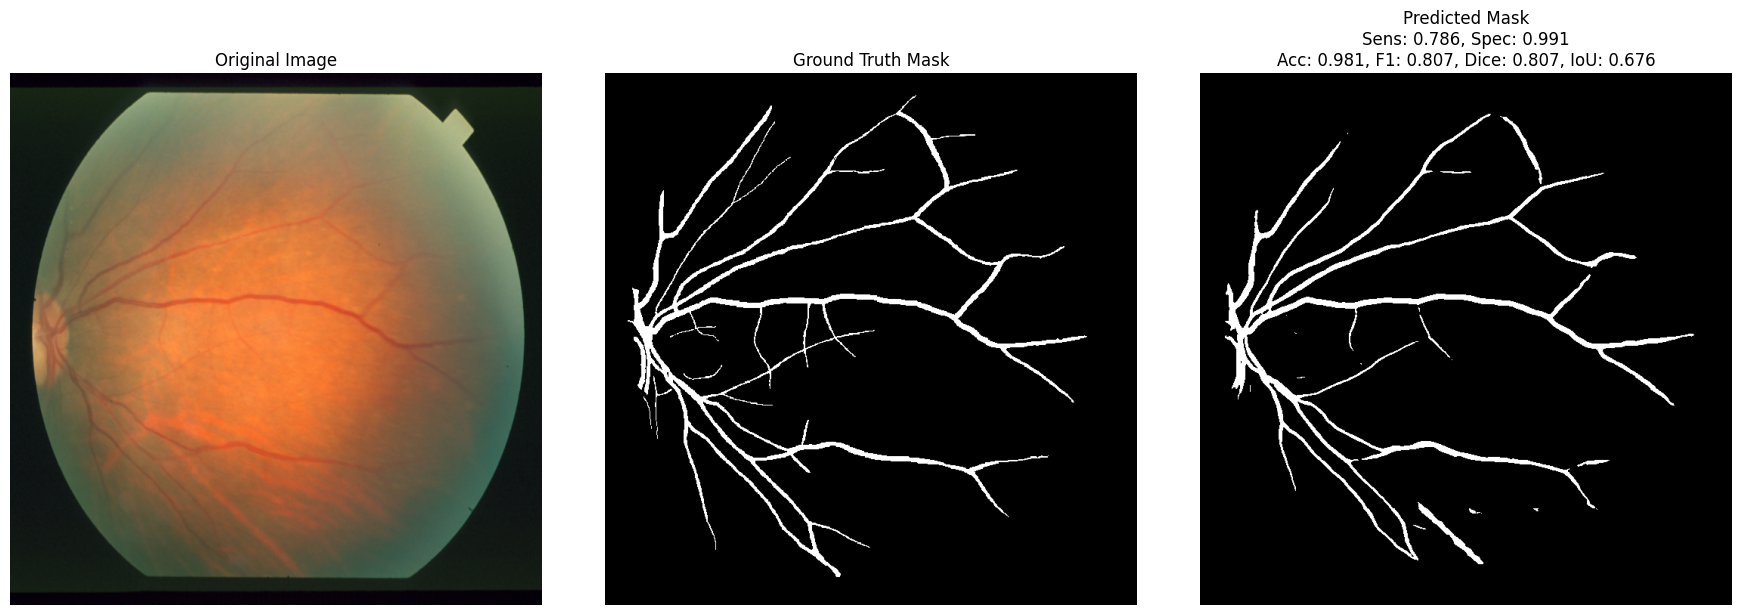

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet original image\original_image_3.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet predicted_mask\predicted_mask_3.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet_ground_truth_mask\ground_truth_mask_3.png
Metrics for Image 3 written to CSV.
Metrics for Image 4: Sens: 0.787, Spec: 0.988, Acc: 0.980, F1: 0.769, Dice: 0.769, IoU: 0.625


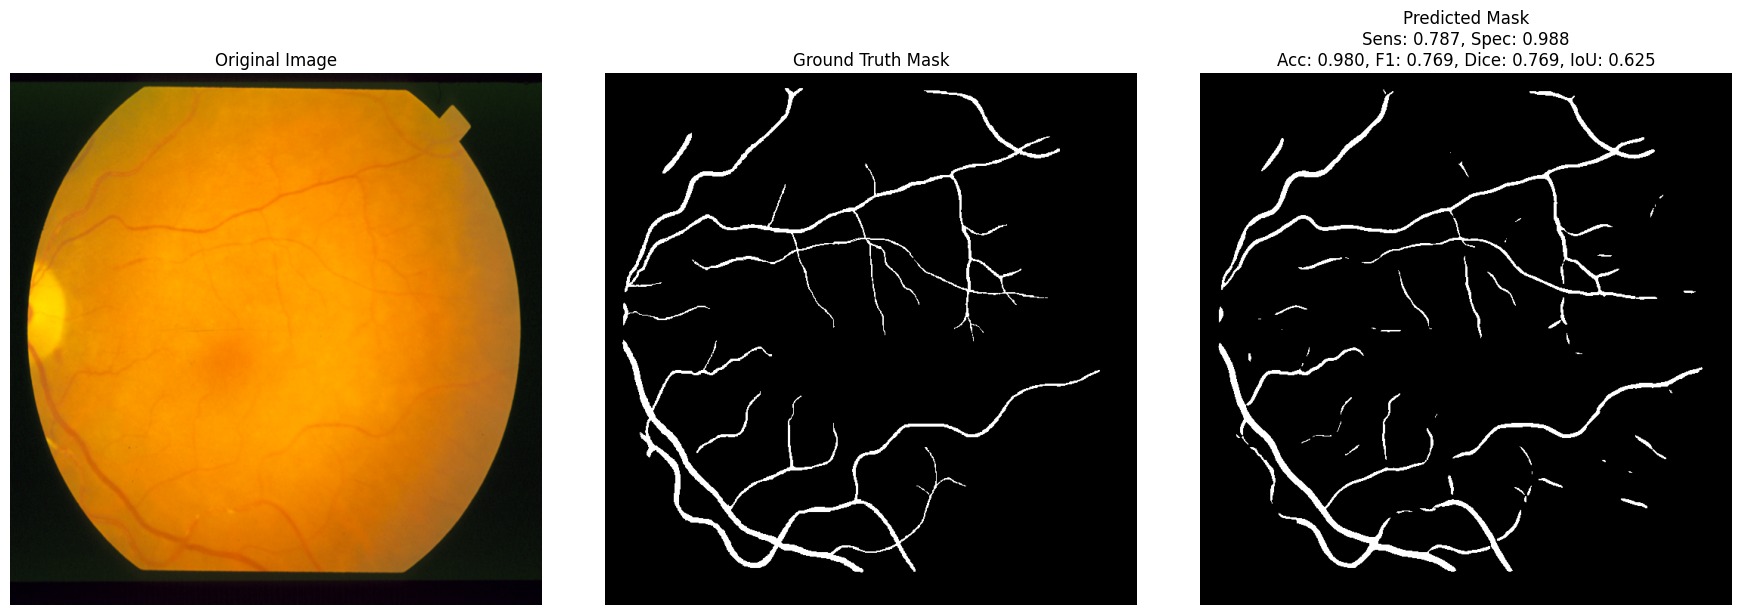

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet original image\original_image_4.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet predicted_mask\predicted_mask_4.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet_ground_truth_mask\ground_truth_mask_4.png
Metrics for Image 4 written to CSV.
Metrics for Image 5: Sens: 0.662, Spec: 0.988, Acc: 0.966, F1: 0.724, Dice: 0.724, IoU: 0.568


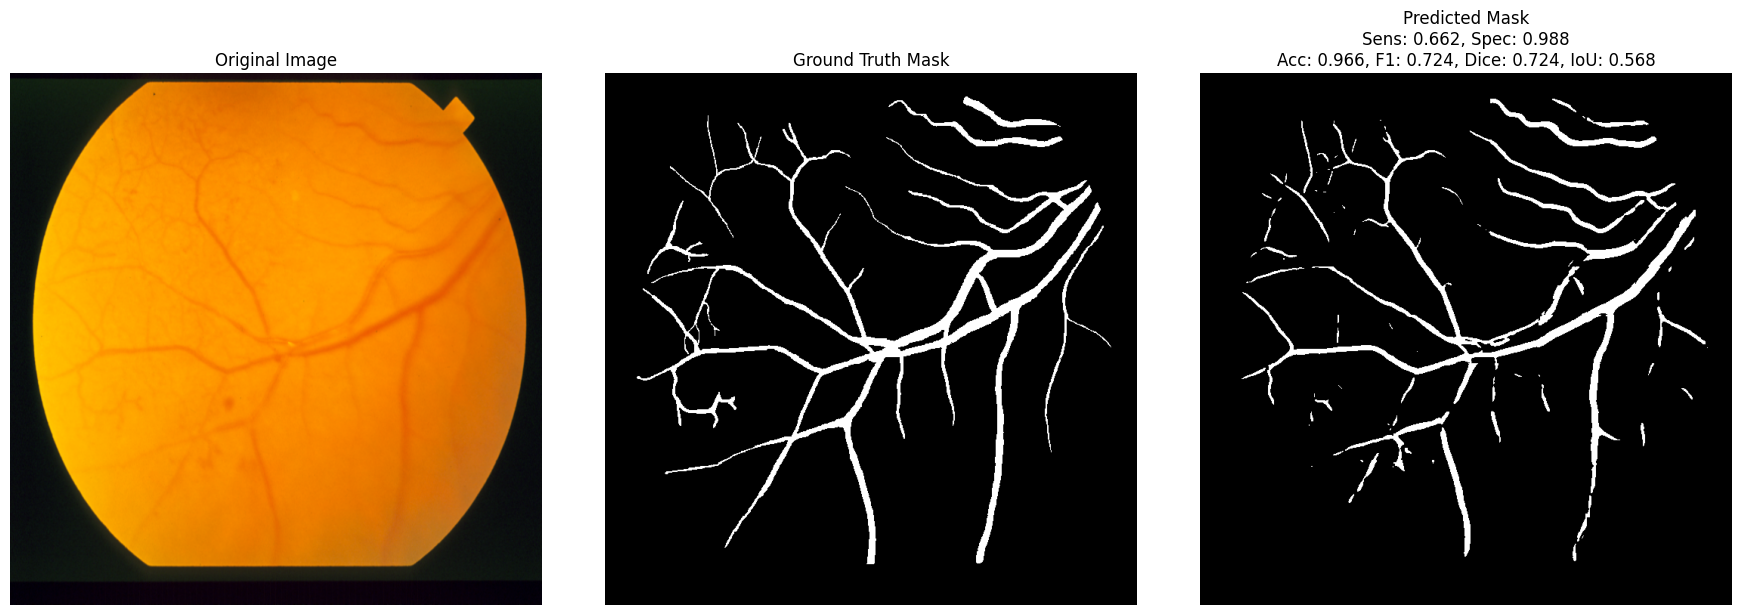

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet original image\original_image_5.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet predicted_mask\predicted_mask_5.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet_ground_truth_mask\ground_truth_mask_5.png
Metrics for Image 5 written to CSV.
All test image metrics saved to C:\Users\AUSTCSE4090\Desktop\STARE\csv files\transunet__metrics.csv


In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

# Directories to save predictions, ground truth masks, and original images
PREDICTIONS_DIR = r'C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet predicted_mask'
GROUND_TRUTH_DIR = r'C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet_ground_truth_mask'
ORIGINAL_IMAGES_DIR = r'C:\Users\AUSTCSE4090\Desktop\STARE\mask\transunet original image'
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(GROUND_TRUTH_DIR, exist_ok=True)
os.makedirs(ORIGINAL_IMAGES_DIR, exist_ok=True)

# Constants
THRESHOLD = 0.5
RESIZE_SIZE = 704
CSV_FILE = r"C:\Users\AUSTCSE4090\Desktop\STARE\csv files\transunet__metrics.csv"

# Define the function to save predicted masks
def save_predicted_mask(pred_mask, idx):
    mask_bin = (pred_mask > THRESHOLD).astype(np.uint8) * 255  # Binarize
    save_path = os.path.join(PREDICTIONS_DIR, f"predicted_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved predicted mask: {save_path}")

# Define the function to save ground truth masks
def save_ground_truth_mask(gt_mask, idx):
    mask_bin = (gt_mask * 255).astype(np.uint8)  # Ensure it is in 0-255 range
    save_path = os.path.join(GROUND_TRUTH_DIR, f"ground_truth_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved ground truth mask: {save_path}")

# Define the function to save the original images
def save_original_image(img, idx):
    save_path = os.path.join(ORIGINAL_IMAGES_DIR, f"original_image_{idx + 1}.png")
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR for saving with OpenCV
    cv2.imwrite(save_path, img_bgr)
    print(f"Saved original image: {save_path}")

# Function to compute per-image metrics
def compute_metrics_per_image(y_true, y_pred):
    y_true = y_true.astype(np.uint8)
    y_pred = y_pred.astype(np.uint8)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    sensitivity = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    f1_score = 2 * precision * sensitivity / (precision + sensitivity + 1e-6)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-6)
    iou = TP / (TP + FP + FN + 1e-6)

    return sensitivity, specificity, accuracy, f1_score, dice, iou

# Initialize CSV file and write header
def initialize_csv():
    with open(CSV_FILE, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Image_Index", "Sensitivity", "Specificity", "Accuracy", "F1_Score", "Dice", "IoU"])

# Write metrics to CSV
def write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou):
    with open(CSV_FILE, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([idx + 1, sens, spec, acc, f1, dice, iou])
    print(f"Metrics for Image {idx + 1} written to CSV.")

# Modify the visualization function to show original image, ground truth, and predicted mask
def visualize_metrics_and_save_prediction(model, img_path, mask_path, idx):
    # Predict mask for the image
    img, pred_mask = predict_full_image(model, img_path)  # Ensure this function is defined
    
    # Check if the prediction and image are correct
    if img is None or pred_mask is None:
        print(f"Prediction failed for image {img_path}")
        return

    # Read and preprocess the ground truth mask
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0
    
    # Apply thresholding to both ground truth and predicted masks to ensure they are binary
    gt_mask_bin = (gt_mask >= 0.5).astype(np.uint8)  # Ground truth as binary (0 or 1)
    pred_mask_bin = (pred_mask >= THRESHOLD).astype(np.uint8)  # Predicted mask as binary (0 or 1)
    
    # Compute metrics
    sens, spec, acc, f1, dice, iou = compute_metrics_per_image(gt_mask_bin, pred_mask_bin)
    
    # Print the metrics to verify if they are being calculated correctly
    print(f"Metrics for Image {idx + 1}: Sens: {sens:.3f}, Spec: {spec:.3f}, Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")

    # Plot the original image, ground truth, and predicted mask
    plt.figure(figsize=(18, 6))  # Increase the size to accommodate all 3 images
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    
    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title(f"Predicted Mask\nSens: {sens:.3f}, Spec: {spec:.3f}\n"
              f"Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    # Save the original image, predicted mask, and ground truth mask
    save_original_image(img, idx)
    save_predicted_mask(pred_mask, idx)
    save_ground_truth_mask(gt_mask, idx)

    # Write the metrics to the CSV file
    write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou)

# Initialize the CSV file with the header
initialize_csv()

# Example usage: 
for idx, (img_path, mask_path) in enumerate(zip(test_images, test_masks)):
    visualize_metrics_and_save_prediction(model, img_path, mask_path, idx)

print(f"All test image metrics saved to {CSV_FILE}")


In [23]:
import os

# Define the folder path to save the model
folder_path = r'C:\Users\AUSTCSE4090\Desktop\STARE\predictions\prediction'  # Update this path if needed
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Define the model save path
model_save_path = os.path.join(folder_path, 'deepla_model.h5')

# Save the model in H5 format
model.save(model_save_path)
print(f"Saved model to {model_save_path}")


Saved model to C:\Users\AUSTCSE4090\Desktop\STARE\predictions\prediction\deeplabv3+1_model.h5


In [16]:
from tensorflow.keras import backend as K

# Clear any previous models and free memory
K.clear_session()
